In [1]:
import pandas as pd
from pandas import Series, DataFrame

In [9]:
titanic_df=pd.read_csv(r"C:\Users\RisterBarretoPombo\Documents\Python Training\Titanic Project\train.csv")

In [3]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
#Questions for this project
#1. Who were the passengers on the Titanic (Ages, Gender, Class,... etc)
#2. What deck were the passengers on and how does that relate to their class?
#3. Where did the passengers come from
#4. Who was alone and who with family?
#5. What factors helped someone survive the sinking?

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Text(0.5, 0.98, 'Titanic Passengers per Sex')

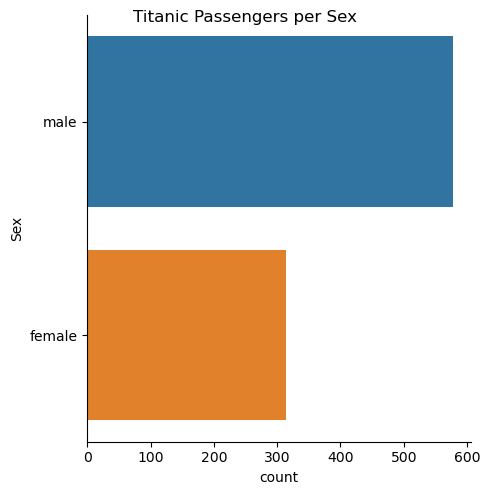

In [6]:
c=sns.catplot(y='Sex',data=titanic_df, kind='count')
c.fig.suptitle('Titanic Passengers per Sex')

Text(0.5, 0.98, 'Titanic Passengers per Sex and Class')

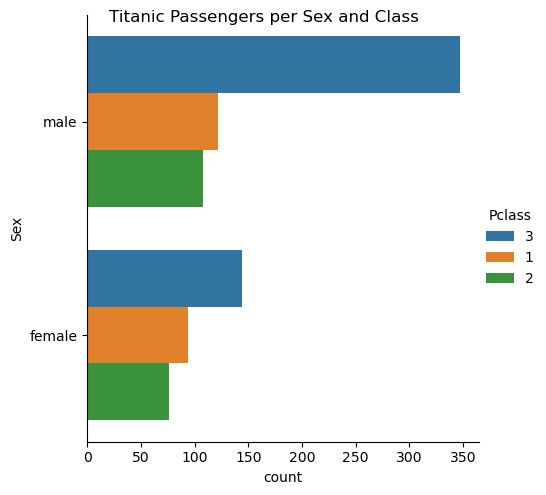

In [7]:
titanic_df['Pclass']=titanic_df['Pclass'].astype(str) #making sure the Pclass is a string so that it can be used for a legend

c=sns.catplot(y='Sex',data=titanic_df, kind='count',hue='Pclass')

c.fig.suptitle('Titanic Passengers per Sex and Class')

Text(0.5, 0.98, 'Titanic Passengers per Class and Sex')

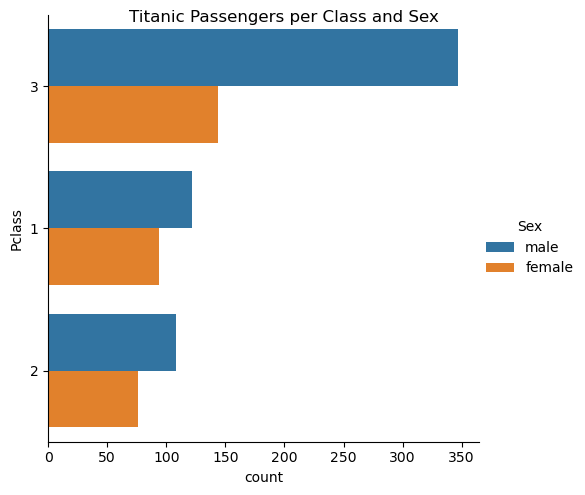

In [8]:
c=sns.catplot(y='Pclass',data=titanic_df,kind='count',hue='Sex')

c.fig.suptitle('Titanic Passengers per Class and Sex')

In [38]:
def male_female_child(passenger): #create a function to pass passenger as an argument
    age, sex = passenger #passenger is a two-value argument with age and sex
    if age < 16:
        return 'child'
    else:
        return sex

In [39]:
titanic_df['person']=titanic_df[['Age','Sex']].apply(male_female_child,axis=1)

In [40]:
titanic_df[0:10]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Alone,Survivor,person
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,With Family,no,male
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,With Family,yes,female
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Alone,yes,female
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,With Family,yes,female
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Alone,no,male
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,Alone,no,male
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,Alone,no,male
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,With Family,no,child
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,With Family,yes,female
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,With Family,yes,child


Text(0.5, 0.98, 'Titanic Passenger per Class and Person')

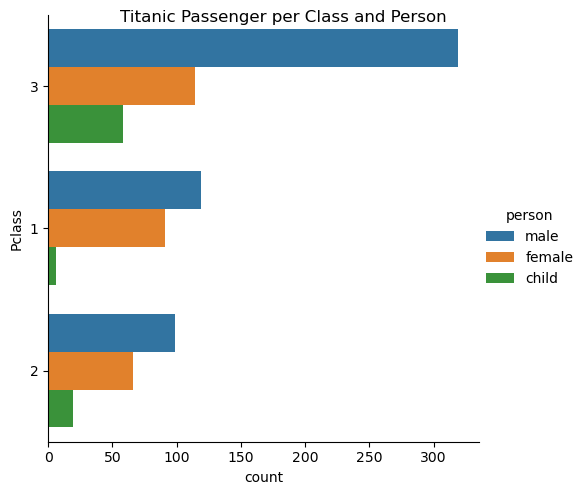

In [12]:
c= sns.catplot(y='Pclass',data=titanic_df,kind='count',hue='person')
c.fig.suptitle('Titanic Passenger per Class and Person')

Text(0.5, 1.0, 'Titanic Passenger Age Distribution')

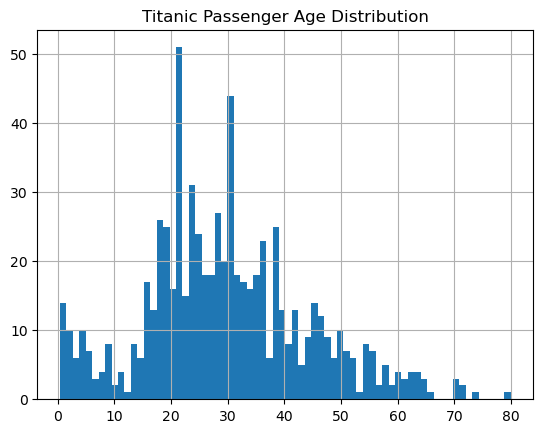

In [13]:
titanic_df['Age'].hist(bins=70)
plt.title('Titanic Passenger Age Distribution')

In [14]:
Age = titanic_df['Age'].mean()
print ("Avg Age of Titanic Passengers is", round(Age,2))


Avg Age of Titanic Passengers is 29.7


In [38]:
titanic_df['person'].value_counts()

person
male      537
female    271
child      83
Name: count, dtype: int64

C:\Users\RisterBarretoPombo\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\RisterBarretoPombo\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


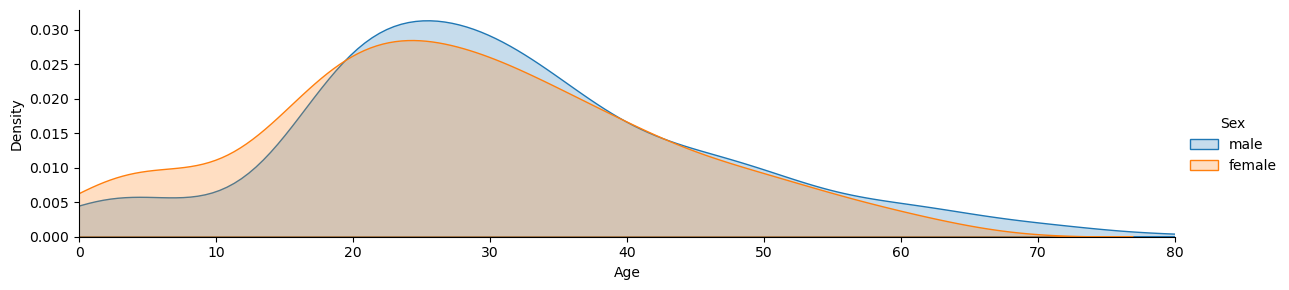

In [43]:
titanic_df=titanic_df.replace([np.inf,-np.inf],np.nan)

fig = sns.FacetGrid(titanic_df,hue='Sex',aspect=4)
fig.map(sns.kdeplot,'Age',fill=True)

oldest=titanic_df['Age'].max()

fig.set(xlim=(0,oldest))

fig.add_legend()

C:\Users\RisterBarretoPombo\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\RisterBarretoPombo\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\RisterBarretoPombo\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


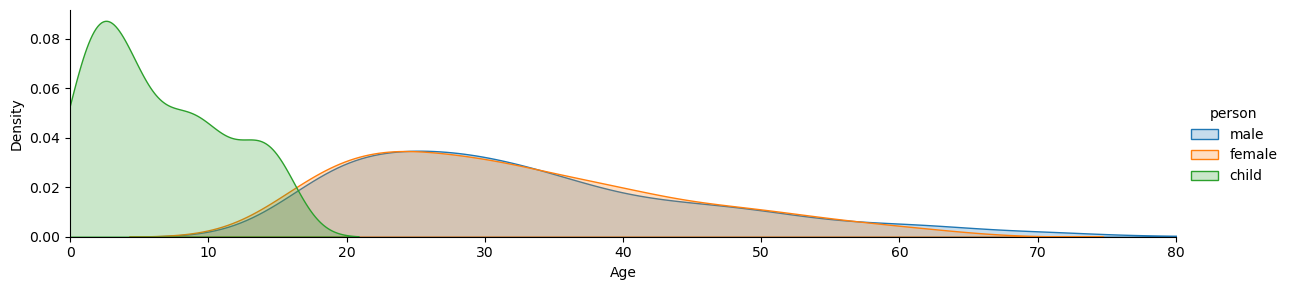

In [44]:
titanic_df=titanic_df.replace([np.inf,-np.inf],np.nan)

fig = sns.FacetGrid(titanic_df,hue='person',aspect=4)
fig.map(sns.kdeplot,'Age',fill=True)

oldest=titanic_df['Age'].max()

fig.set(xlim=(0,oldest))

fig.add_legend()

C:\Users\RisterBarretoPombo\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\RisterBarretoPombo\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\RisterBarretoPombo\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


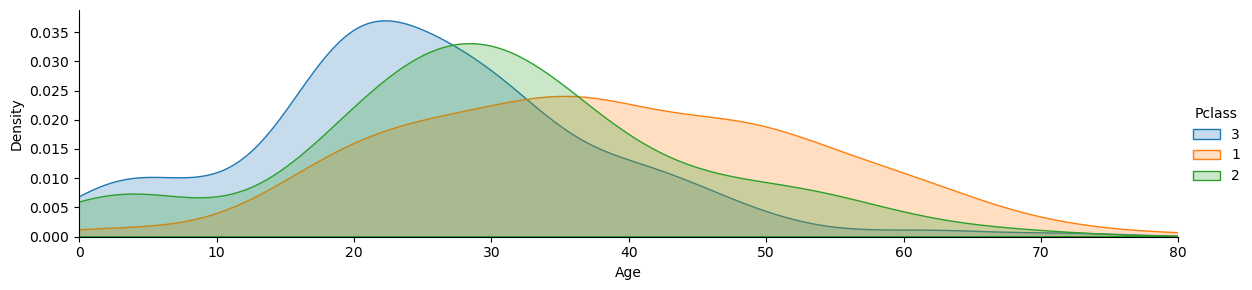

In [45]:
titanic_df=titanic_df.replace([np.inf,-np.inf],np.nan)

fig = sns.FacetGrid(titanic_df,hue='Pclass',aspect=4)
fig.map(sns.kdeplot,'Age',fill=True)

oldest=titanic_df['Age'].max()

fig.set(xlim=(0,oldest))

fig.add_legend()

In [48]:
titanic_df.head(15)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,person
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,male
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,female
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,female
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,female
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,male
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,male
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,male
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,child
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,female
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,child


In [61]:
deck=titanic_df['Cabin'].dropna()

In [62]:
deck.head()

1      C85
3     C123
6      E46
10      G6
11    C103
Name: Cabin, dtype: object

Text(0.5, 0.98, 'Titanic Passengers per Cabin Level')

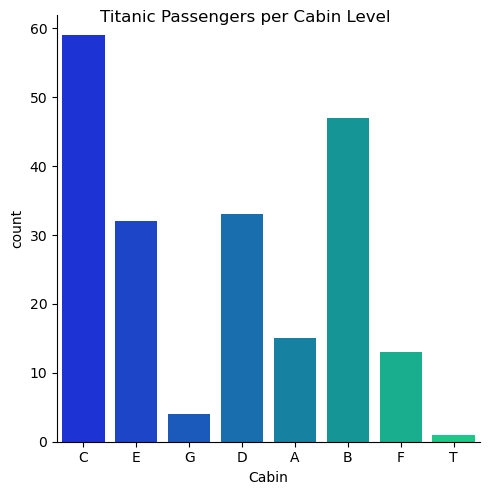

In [63]:
levels = [] #creates a blank list
for level in deck: #loops the level in the deck dataset, which is the cabin name
    levels.append(level[0]) #level[0] extracts the first character of the cabin name

cabin_df=DataFrame(levels) #turns the levels into a dataframe
cabin_df.columns=['Cabin'] #gives the dataframe a column name
c=sns.catplot(x='Cabin',data=cabin_df,kind='count',palette='winter')
c.fig.suptitle("Titanic Passengers per Cabin Level")

Text(0.5, 0.98, 'Container Passenger per Cabin')

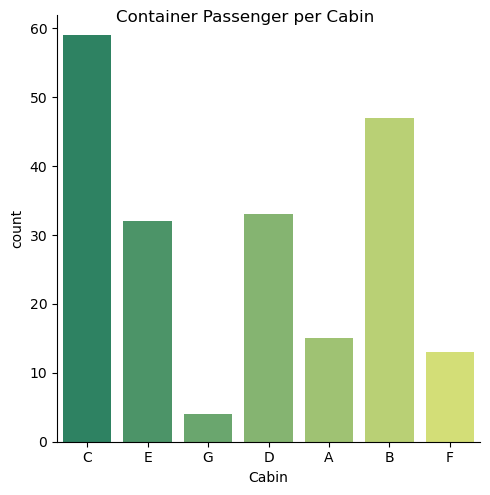

In [64]:
cabin_df=cabin_df[cabin_df.Cabin!='T']
c=sns.catplot(x='Cabin',data=cabin_df,kind='count',palette='summer')
c.fig.suptitle('Container Passenger per Cabin')

In [60]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,person
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,male
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,female
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,female
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,female
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,male


Text(0.5, 0.98, "Titanic Survivors' Origin per Class")

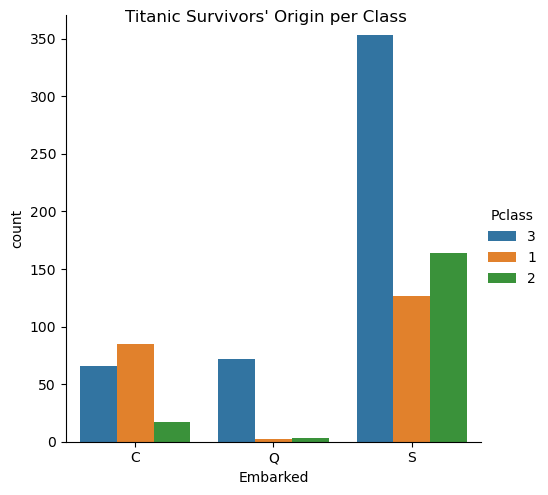

In [64]:
c=sns.catplot(x='Embarked',data=titanic_df,kind='count',hue='Pclass',order=['C','Q','S'])
c.fig.suptitle("Titanic Passengers' Origin per Class")

In [24]:
def solitary(family):
    SibSp,Parch = family
    if SibSp+Parch ==0:
        return 'alone'
    else:
        return 'with family'

titanic_df['onboarded party']=titanic_df[['SibSp','Parch']].apply(solitary,axis=1)

In [34]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,person,onboarded party
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,male,with family
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,female,with family
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,female,alone
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,female,with family
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,male,alone


Text(0.5, 0.98, 'Titanic Passengers per Class and Onboarded Pary')

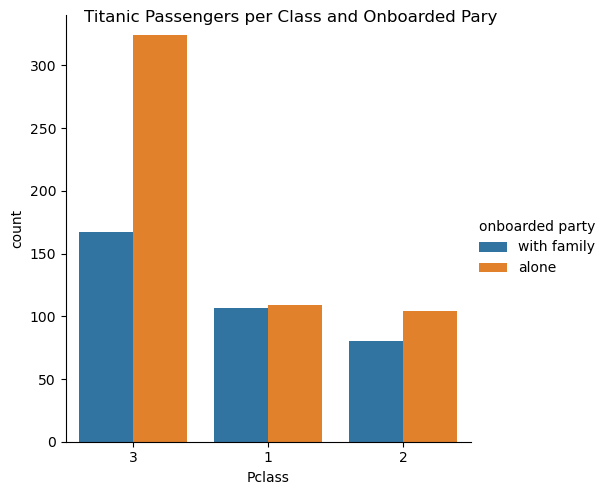

In [27]:
c=sns.catplot(x='Pclass',data=titanic_df,kind='count',hue='onboarded party')
c.fig.suptitle("Titanic Passengers per Class and Onboarded Pary")

In [11]:
titanic_df['Alone']=titanic_df.SibSp+titanic_df.Parch
titanic_df['Alone']
titanic_df['Alone'].loc[titanic_df['Alone']>0]='With Family'
titanic_df['Alone'].loc[titanic_df['Alone']==0]='Alone'

C:\Users\RisterBarretoPombo\AppData\Local\Temp\ipykernel_17844\3698823736.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  titanic_df['Alone'].loc[titanic_df['Alone']>0]='With Family'
C:\Users\RisterBarretoPombo\AppData\Local\Temp\ipykernel_17844\3698823736.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'With Family' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  titanic_df['Alone'].loc[titanic_df['Alone']>0]='With Family'


Text(0.5, 0.98, 'Titanic Passengers with Family vs Alone')

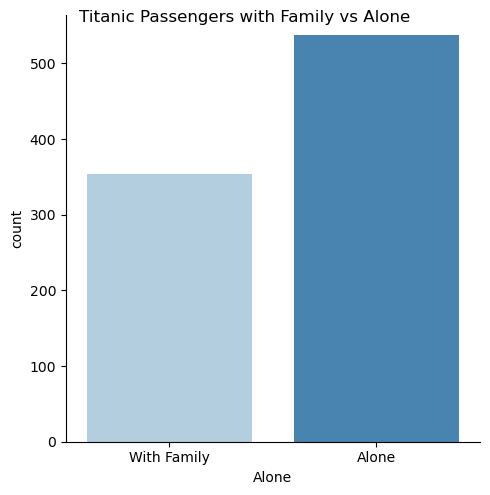

In [14]:
c=sns.catplot(x='Alone',data=titanic_df,kind='count',palette='Blues')
c.fig.suptitle("Titanic Passengers with Family vs Alone")

Text(0.5, 0.98, 'Survivors vs Non Survivors in the Titanic Sinking')

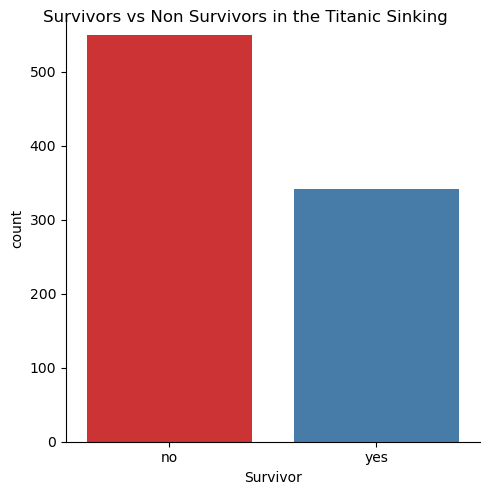

In [17]:
titanic_df['Survivor']=titanic_df.Survived.map({0:'no',1:'yes'})

c=sns.catplot(x='Survivor',data=titanic_df,kind='count',palette='Set1')
c.fig.suptitle("Survivors vs Non Survivors in the Titanic Sinking")

Text(0.5, 0.98, 'Number of Survivors per Class')

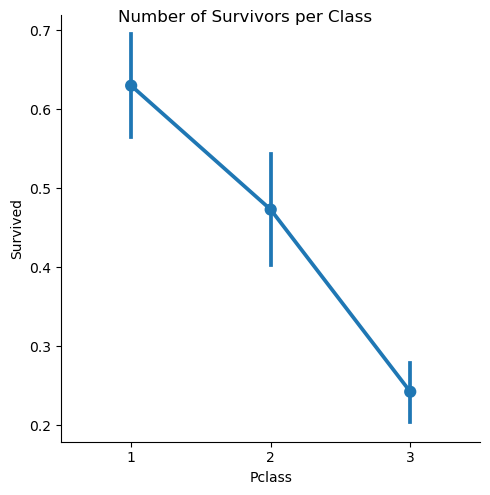

In [34]:
titanic_df['Pclass'] = titanic_df['Pclass'].astype(int) #turning Pclass and Survived into numeric values
titanic_df['Survived'] = titanic_df['Survived'].astype(int)

c=sns.catplot(x='Pclass',y='Survived',data=titanic_df,kind='point')
c.fig.suptitle("Number of Survivors per Class")

Text(0.5, 0.98, 'Number of Survivors per Class and Person')

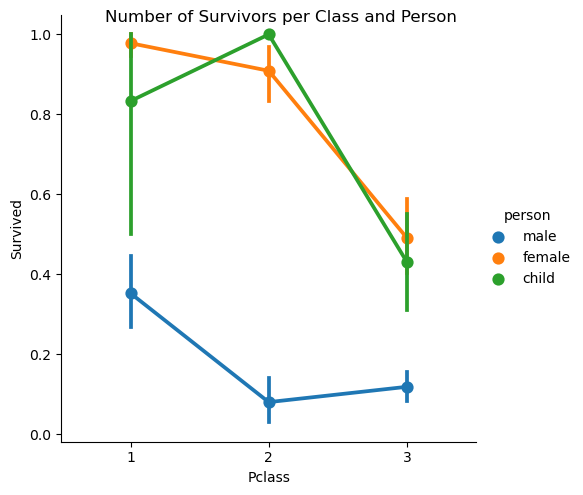

In [41]:
c=sns.catplot(x='Pclass',y='Survived',hue='person',data=titanic_df,kind='point')
c.fig.suptitle("Number of Survivors per Class and Person")

Text(0.5, 1.05, 'Linear Regression of Survivors per Age Group')

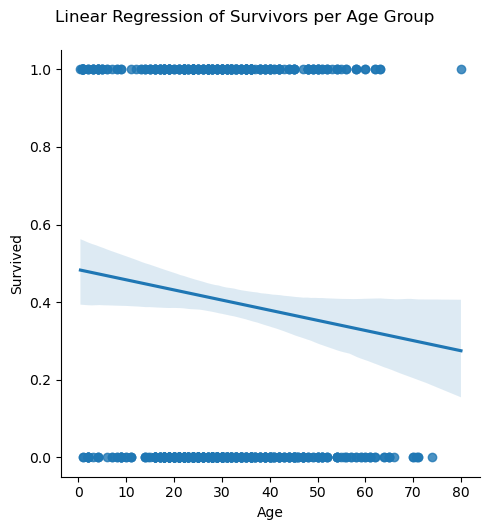

In [44]:
c=sns.lmplot(x='Age',y='Survived',data=titanic_df)
c.fig.suptitle("Linear Regression of Survivors per Age Group",y=1.05)

Text(0.5, 1.05, 'Linear Regression of Survivors per Age and Class')

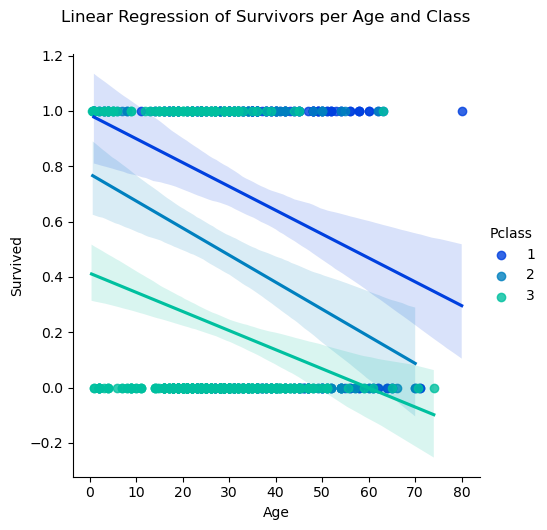

In [47]:
c=sns.lmplot(x='Age',y='Survived',hue='Pclass',data=titanic_df,palette='winter')
c.fig.suptitle("Linear Regression of Survivors per Age and Class",y=1.05)

Text(0.5, 1.03, 'Survivors per Class and Generarion')

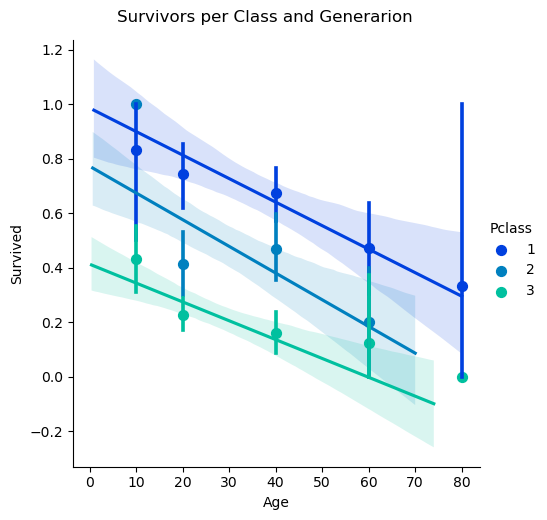

In [49]:
generations=[10,20,40,60,80]

c=sns.lmplot(x='Age',y='Survived',hue='Pclass',data=titanic_df,palette='winter',x_bins=generations)

c.fig.suptitle("Survivors per Class and Generarion",y=1.03)

Text(0.5, 1.03, 'Survivors per Sex and Generarion')

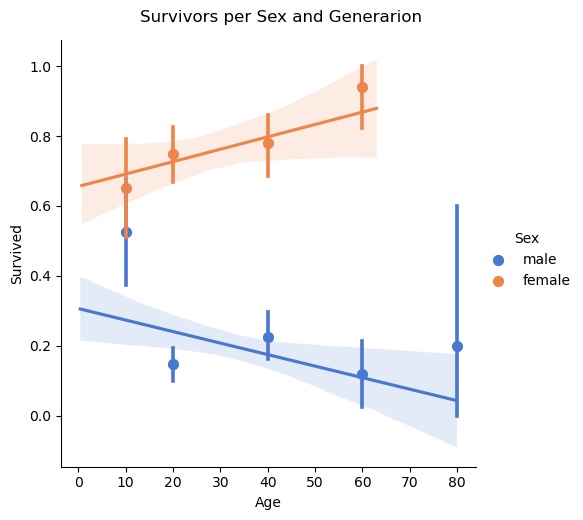

In [51]:
c=sns.lmplot(x='Age',y='Survived',hue='Sex',data=titanic_df,palette='muted',x_bins=generations)

c.fig.suptitle("Survivors per Sex and Generarion",y=1.03)

In [80]:
titanic_df['cabin level']=titanic_df['Cabin'].str[0]
titanic_df['cabin level']

0      NaN
1        C
2      NaN
3        C
4      NaN
      ... 
886    NaN
887      B
888    NaN
889      C
890    NaN
Name: cabin level, Length: 891, dtype: object

In [81]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Alone,Survivor,person,cabin level
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,With Family,no,male,NaN
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,With Family,yes,female,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Alone,yes,female,NaN
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,With Family,yes,female,C
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Alone,no,male,NaN
